In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, lil_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.patches import FancyArrowPatch

import csv
import pandas as pd

Total nodes: 16
Total DOFs: 48
Total elements: 21
Columns: 12
Beams: 9
Fixed DOFs: 12
Applied loads:
  Node (1,2): Fx = 50.0 kN
  Node (1,3): Fx = 50.0 kN
  Node (1,4): Fx = 50.0 kN

Solution completed. Maximum displacement: 7.461357 mm

RESULTS SUMMARY

NODAL DISPLACEMENTS AND ROTATIONS:
Node  |   ux (mm)   |   uy (mm)   |   θz (rad)
--------------------------------------------------
(1,1) |     0.0000 |     0.0000 |   0.000000
(1,2) |     2.6445 |     0.0220 |  -0.000919
(1,3) |     5.6722 |     0.0334 |  -0.000652
(1,4) |     7.4614 |     0.0371 |  -0.000340
(2,1) |     0.0000 |     0.0000 |   0.000000
(2,2) |     2.6020 |    -0.0027 |  -0.000696
(2,3) |     5.6222 |    -0.0039 |  -0.000536
(2,4) |     7.4090 |    -0.0044 |  -0.000237
(3,1) |     0.0000 |     0.0000 |   0.000000
(3,2) |     2.5726 |     0.0025 |  -0.000692
(3,3) |     5.5905 |     0.0038 |  -0.000536
(3,4) |     7.3778 |     0.0043 |  -0.000237
(4,1) |     0.0000 |     0.0000 |   0.000000
(4,2) |     2.5552 |    -0.

c:\Users\ziyou\.conda\envs\LLMENV_py310\lib\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


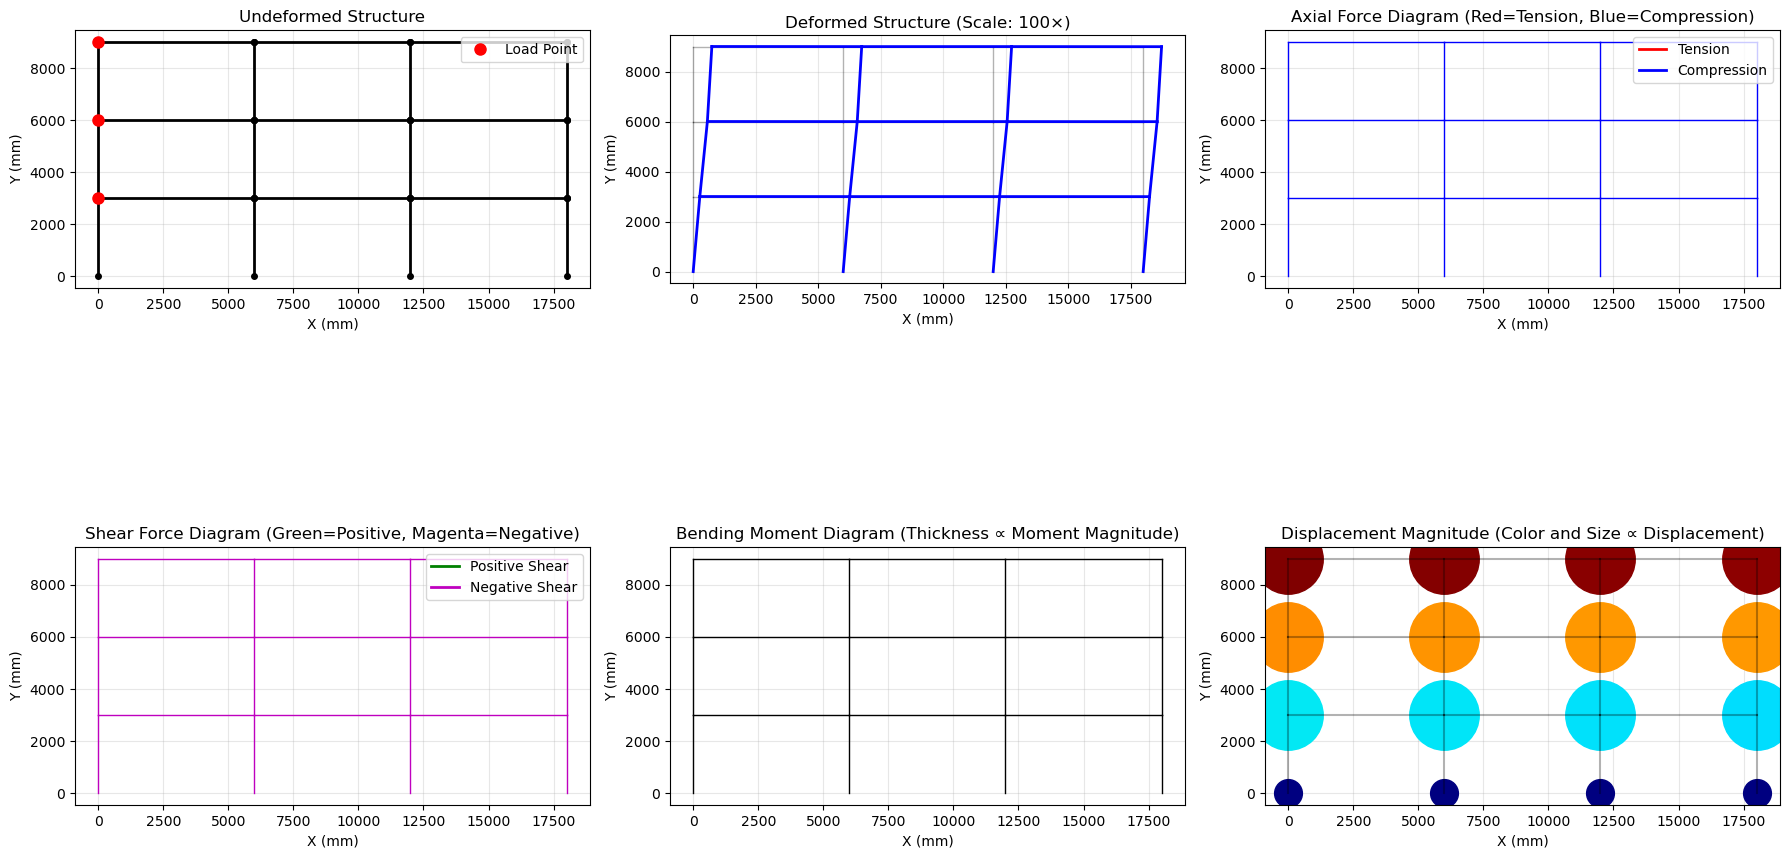


DETAILED FORCES FOR SELECTED ELEMENTS

Element with Maximum Axial Force (Element 14, beam):
  Node 1: N = 41.87 kN, V = -5.92 kN, M = -18.86 kN·m
  Node 2: N = -41.87 kN, V = 5.92 kN, M = -16.67 kN·m

Element with Maximum Shear Force (Element 3, column):
  Node 1: N = 4.25 kN, V = 42.01 kN, M = 77.85 kN·m
  Node 2: N = -4.25 kN, V = -42.01 kN, M = 48.17 kN·m

Element with Maximum Bending Moment (Element 3, column):
  Node 1: N = 4.25 kN, V = 42.01 kN, M = 77.85 kN·m
  Node 2: N = -4.25 kN, V = -42.01 kN, M = 48.17 kN·m

ADDITIONAL ANALYSIS

Shear Deformation Effects:
  Columns: Shear deformation parameter φ = 0.055467
    Note: φ > 0.01 indicates shear deformation may be significant
  Beams: Shear deformation parameter φ = 0.013867
    Note: φ > 0.01 indicates shear deformation may be significant

Reactions at Supports (Bottom Nodes):
  Node (1,1):
    Rx =  -34.13 kN, Ry =  -35.19 kN, Mz =   70.80 kN·m
  Node (2,1):
    Rx =  -42.01 kN, Ry =    4.25 kN, Mz =   77.85 kN·m
  Node (3,1)

In [6]:
# ============================================
# 1. GEOMETRY AND MATERIAL PROPERTIES
# ============================================
# Units: mm, N, MPa
L = 6000.0  # bay span (mm)
H = 3000.0  # floor height (mm)

# Section properties
b_col = 400.0  # column width (mm)
h_col = 400.0  # column depth (mm)
b_beam = 400.0  # beam width (mm)
h_beam = 400.0  # beam depth (mm)

# Material properties
E = 3.0e4  # MPa
nu = 0.3  # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus

# Load
F = 50000.0  # N (50 kN)

# ============================================
# 2. NODE DEFINITION
# ============================================
# Node numbering: (x_position, y_position)
# x positions: 0, 6000, 12000, 18000
# y positions: 0, 3000, 6000, 9000
x_coords = [0, L, 2*L, 3*L]
y_coords = [0, H, 2*H, 3*H]

# Create node list with coordinates and global DOF indices
nodes = []
node_dict = {}  # Mapping from (i,j) to node index
node_counter = 0

for i in range(4):  # x positions
    for j in range(4):  # y positions
        nodes.append({
            'id': node_counter,
            'x': x_coords[i],
            'y': y_coords[j],
            'coords': (i, j),  # (x_index, y_index)
            'dofs': [node_counter*3, node_counter*3+1, node_counter*3+2]  # ux, uy, θz
        })
        node_dict[(i, j)] = node_counter
        node_counter += 1

n_nodes = len(nodes)
print(f"Total nodes: {n_nodes}")
print(f"Total DOFs: {n_nodes * 3}")

# ============================================
# 3. ELEMENT DEFINITION
# ============================================
elements = []
elem_counter = 0

# Column elements (vertical)
for i in range(4):  # x positions
    for j in range(3):  # y intervals: 0-1, 1-2, 2-3
        node1 = node_dict[(i, j)]
        node2 = node_dict[(i, j+1)]
        
        # Element properties
        length = np.sqrt((nodes[node2]['x'] - nodes[node1]['x'])**2 + 
                         (nodes[node2]['y'] - nodes[node1]['y'])**2)
        
        elements.append({
            'id': elem_counter,
            'type': 'column',
            'nodes': [node1, node2],
            'length': length,
            'angle': 90.0,  # vertical elements
            'A': b_col * h_col,  # area (mm²)
            'I': b_col * h_col**3 / 12.0,  # moment of inertia (mm⁴)
            'As': b_col * h_col * 5/6,  # shear area for rectangular section
            'b': b_col,
            'h': h_col
        })
        elem_counter += 1

# Beam elements (horizontal)
for i in range(3):  # x intervals: 0-1, 1-2, 2-3
    for j in range(1, 4):  # floor positions: 1, 2, 3 (y_index)
        node1 = node_dict[(i, j)]
        node2 = node_dict[(i+1, j)]
        
        # Element properties
        length = np.sqrt((nodes[node2]['x'] - nodes[node1]['x'])**2 + 
                         (nodes[node2]['y'] - nodes[node1]['y'])**2)
        
        elements.append({
            'id': elem_counter,
            'type': 'beam',
            'nodes': [node1, node2],
            'length': length,
            'angle': 0.0,  # horizontal elements
            'A': b_beam * h_beam,  # area (mm²)
            'I': b_beam * h_beam**3 / 12.0,  # moment of inertia (mm⁴)
            'As': b_beam * h_beam * 5/6,  # shear area for rectangular section
            'b': b_beam,
            'h': h_beam
        })
        elem_counter += 1

print(f"Total elements: {len(elements)}")
print(f"Columns: {len([e for e in elements if e['type']=='column'])}")
print(f"Beams: {len([e for e in elements if e['type']=='beam'])}")

# ============================================
# 4. ELEMENT STIFFNESS MATRIX FUNCTION
# ============================================
def element_stiffness_matrix(elem):
    """Compute element stiffness matrix in global coordinates"""
    L = elem['length']
    A = elem['A']
    I = elem['I']
    As = elem['As']
    
    # Local stiffness matrix (6x6) for 2D frame element with shear deformation
    # DOFs: [u1, v1, θ1, u2, v2, θ2]
    
    # Axial stiffness
    k_axial = (E * A / L) * np.array([
        [1, 0, 0, -1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [-1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]
    ])
    
    # Bending stiffness (with shear deformation)
    phi = 12 * E * I / (G * As * L**2)  # Shear deformation parameter
    
    k_bending = (E * I / (L**3 * (1 + phi))) * np.array([
        [0, 0, 0, 0, 0, 0],
        [0, 12, 6*L, 0, -12, 6*L],
        [0, 6*L, (4+phi)*L**2, 0, -6*L, (2-phi)*L**2],
        [0, 0, 0, 0, 0, 0],
        [0, -12, -6*L, 0, 12, -6*L],
        [0, 6*L, (2-phi)*L**2, 0, -6*L, (4+phi)*L**2]
    ])
    
    # Local stiffness matrix
    k_local = k_axial + k_bending
    
    # Transformation matrix
    angle_rad = np.radians(elem['angle'])
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    
    T = np.array([
        [c, s, 0, 0, 0, 0],
        [-s, c, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, c, s, 0],
        [0, 0, 0, -s, c, 0],
        [0, 0, 0, 0, 0, 1]
    ])
    
    # Transform to global coordinates
    k_global = T.T @ k_local @ T
    
    return k_global

# ============================================
# 5. ASSEMBLE GLOBAL STIFFNESS MATRIX
# ============================================
n_dofs = n_nodes * 3
K = lil_matrix((n_dofs, n_dofs), dtype=np.float64)

for elem in elements:
    # Get element stiffness matrix
    k_elem = element_stiffness_matrix(elem)
    
    # Get global DOF indices for this element
    dofs = []
    for node_id in elem['nodes']:
        dofs.extend(nodes[node_id]['dofs'])
    
    # Assemble into global matrix
    for i in range(6):
        for j in range(6):
            K[dofs[i], dofs[j]] += k_elem[i, j]

K = K.tocsc()  # Convert to compressed sparse column format

# ============================================
# 6. APPLY BOUNDARY CONDITIONS
# ============================================
# Bottom nodes are fixed (nodes with y=0)
fixed_dofs = []
for node in nodes:
    if node['y'] == 0:  # Bottom nodes
        fixed_dofs.extend(node['dofs'])

print(f"Fixed DOFs: {len(fixed_dofs)}")

# ============================================
# 7. APPLY LOADS
# ============================================
F_global = np.zeros(n_dofs)

# Apply horizontal force F=50 kN at nodes (1,2), (1,3), (1,4)
# Node indices: (0,0) is node 0, (1,0) is node 4, (1,1) is node 5, etc.
# Actually, node_dict gives mapping from (i,j) to node index

load_nodes = [
    (1, 2),  # node (1,2)
    (1, 3),  # node (1,3)
    (1, 4)   # node (1,4)
]

for (i, j) in load_nodes:
    # Note: our indices are 0-based, but problem uses 1-based
    # (1,2) corresponds to x_index=1, y_index=2
    node_id = node_dict[(i-1, j-1)]  # Convert to 0-based
    ux_dof = nodes[node_id]['dofs'][0]  # ux DOF
    F_global[ux_dof] = F

print("Applied loads:")
for (i, j) in load_nodes:
    node_id = node_dict[(i-1, j-1)]
    print(f"  Node ({i},{j}): Fx = {F/1000:.1f} kN")

# ============================================
# 8. SOLVE SYSTEM
# ============================================
# Apply boundary conditions by modifying stiffness matrix and force vector
K_mod = K.copy()
F_mod = F_global.copy()

# For fixed DOFs, set diagonal to 1 and off-diagonals to 0
for dof in fixed_dofs:
    K_mod[dof, :] = 0
    K_mod[:, dof] = 0
    K_mod[dof, dof] = 1
    F_mod[dof] = 0

# Solve the system
U = spsolve(K_mod, F_mod)

print(f"\nSolution completed. Maximum displacement: {np.max(np.abs(U)):.6f} mm")

# ============================================
# 9. POST-PROCESSING: ELEMENT FORCES
# ============================================
def compute_element_forces(elem, U):
    """Compute axial force, shear force, and bending moment for an element"""
    L = elem['length']
    A = elem['A']
    I = elem['I']
    As = elem['As']
    
    # Get element displacements in global coordinates
    dofs = []
    for node_id in elem['nodes']:
        dofs.extend(nodes[node_id]['dofs'])
    
    U_elem_global = U[dofs]
    
    # Transformation matrix
    angle_rad = np.radians(elem['angle'])
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    
    T = np.array([
        [c, s, 0, 0, 0, 0],
        [-s, c, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, c, s, 0],
        [0, 0, 0, -s, c, 0],
        [0, 0, 0, 0, 0, 1]
    ])
    
    # Transform to local coordinates
    U_elem_local = T @ U_elem_global
    
    # Local stiffness matrix
    phi = 12 * E * I / (G * As * L**2)
    
    k_axial = (E * A / L) * np.array([
        [1, 0, 0, -1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [-1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]
    ])
    
    k_bending = (E * I / (L**3 * (1 + phi))) * np.array([
        [0, 0, 0, 0, 0, 0],
        [0, 12, 6*L, 0, -12, 6*L],
        [0, 6*L, (4+phi)*L**2, 0, -6*L, (2-phi)*L**2],
        [0, 0, 0, 0, 0, 0],
        [0, -12, -6*L, 0, 12, -6*L],
        [0, 6*L, (2-phi)*L**2, 0, -6*L, (4+phi)*L**2]
    ])
    
    k_local = k_axial + k_bending
    
    # Element forces in local coordinates
    f_local = k_local @ U_elem_local
    
    # Extract forces
    # f_local = [N1, V1, M1, N2, V2, M2]
    N1 = f_local[0] / 1000  # kN (axial force at node 1)
    V1 = f_local[1] / 1000  # kN (shear force at node 1)
    M1 = f_local[2] / 1e6   # kN·m (bending moment at node 1, converted from kN·mm)
    N2 = f_local[3] / 1000  # kN
    V2 = f_local[4] / 1000  # kN
    M2 = f_local[5] / 1e6   # kN·m
    
    return {
        'N': [N1, N2],  # kN
        'V': [V1, V2],  # kN
        'M': [M1, M2],  # kN·m
        'U_local': U_elem_local
    }

# Compute forces for all elements
for elem in elements:
    forces = compute_element_forces(elem, U)
    elem.update(forces)

# ============================================
# 10. RESULTS SUMMARY
# ============================================
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)

# Nodal displacements
print("\nNODAL DISPLACEMENTS AND ROTATIONS:")
print("Node  |   ux (mm)   |   uy (mm)   |   θz (rad)")
print("-"*50)

for node in nodes:
    node_id = node['id']
    ux = U[node_id*3]
    uy = U[node_id*3 + 1]
    theta = U[node_id*3 + 2]
    
    # Get coordinates for display
    i, j = node['coords']
    print(f"({i+1},{j+1}) | {ux:>10.4f} | {uy:>10.4f} | {theta:>10.6f}")

# Element forces summary
print("\n\nELEMENT FORCES (Max values):")
print("Elem | Type   |   N_max (kN)   |   V_max (kN)   |   M_max (kN·m)")
print("-"*60)

for elem in elements:
    N_max = max(abs(elem['N'][0]), abs(elem['N'][1]))
    V_max = max(abs(elem['V'][0]), abs(elem['V'][1]))
    M_max = max(abs(elem['M'][0]), abs(elem['M'][1]))
    
    print(f"{elem['id']:3d} | {elem['type']:6s} | {N_max:>13.2f} | {V_max:>13.2f} | {M_max:>13.2f}")

# Find maximum values
max_ux = max(abs(U[0::3]))
max_uy = max(abs(U[1::3]))
max_theta = max(abs(U[2::3]))

print(f"\nMaximum horizontal displacement: {max_ux:.4f} mm")
print(f"Maximum vertical displacement: {max_uy:.4f} mm")
print(f"Maximum rotation: {max_theta:.6f} rad")

# ============================================
# 11. VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Undeformed structure
ax1 = axes[0, 0]
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    
    ax1.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             'k-', linewidth=2)
    
    # Mark nodes
    ax1.plot(node1['x'], node1['y'], 'ko', markersize=4)
    ax1.plot(node2['x'], node2['y'], 'ko', markersize=4)

# Mark load points
for (i, j) in load_nodes:
    node_id = node_dict[(i-1, j-1)]
    x, y = nodes[node_id]['x'], nodes[node_id]['y']
    ax1.plot(x, y, 'ro', markersize=8, label='Load Point' if (i,j)==load_nodes[0] else "")

ax1.set_title('Undeformed Structure')
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')

# Plot 2: Deformed structure (scaled)
ax2 = axes[0, 1]
scale_factor = 100  # Displacement scale factor for visualization

# Plot undeformed structure (gray)
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    ax2.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             'k-', linewidth=1, alpha=0.3)

# Plot deformed structure
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    
    # Get deformed positions
    x1_def = node1['x'] + U[node1['id']*3] * scale_factor
    y1_def = node1['y'] + U[node1['id']*3+1] * scale_factor
    x2_def = node2['x'] + U[node2['id']*3] * scale_factor
    y2_def = node2['y'] + U[node2['id']*3+1] * scale_factor
    
    ax2.plot([x1_def, x2_def], [y1_def, y2_def], 'b-', linewidth=2)

ax2.set_title(f'Deformed Structure (Scale: {scale_factor}×)')
ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: Axial force diagram
ax3 = axes[0, 2]
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    
    # Get axial force (average of two ends)
    N_avg = (elem['N'][0] + elem['N'][1]) / 2
    
    # Color based on tension/compression
    color = 'r' if N_avg > 0 else 'b'
    linewidth = abs(N_avg) / 50  # Scale linewidth by force magnitude
    
    ax3.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             color=color, linewidth=max(1, linewidth))

# Add colorbar legend
ax3.plot([], [], 'r-', linewidth=2, label='Tension')
ax3.plot([], [], 'b-', linewidth=2, label='Compression')

ax3.set_title('Axial Force Diagram (Red=Tension, Blue=Compression)')
ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Y (mm)')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right')
ax3.set_aspect('equal')

# Plot 4: Shear force diagram
ax4 = axes[1, 0]
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    
    # Get shear force (average of two ends)
    V_avg = (elem['V'][0] + elem['V'][1]) / 2
    
    # Color based on direction
    color = 'g' if V_avg > 0 else 'm'
    linewidth = abs(V_avg) / 20  # Scale linewidth by force magnitude
    
    ax4.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             color=color, linewidth=max(1, linewidth))

ax4.plot([], [], 'g-', linewidth=2, label='Positive Shear')
ax4.plot([], [], 'm-', linewidth=2, label='Negative Shear')

ax4.set_title('Shear Force Diagram (Green=Positive, Magenta=Negative)')
ax4.set_xlabel('X (mm)')
ax4.set_ylabel('Y (mm)')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper right')
ax4.set_aspect('equal')

# Plot 5: Bending moment diagram
ax5 = axes[1, 1]
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    
    # Get bending moment (average magnitude)
    M_avg = (abs(elem['M'][0]) + abs(elem['M'][1])) / 2
    
    # Color based on magnitude
    linewidth = M_avg / 100  # Scale linewidth by moment magnitude
    
    ax5.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             'k-', linewidth=max(1, linewidth))

ax5.set_title('Bending Moment Diagram (Thickness ∝ Moment Magnitude)')
ax5.set_xlabel('X (mm)')
ax5.set_ylabel('Y (mm)')
ax5.grid(True, alpha=0.3)
ax5.set_aspect('equal')

# Plot 6: Displacement magnitude
ax6 = axes[1, 2]
for node in nodes:
    ux = U[node['id']*3]
    uy = U[node['id']*3+1]
    disp_mag = np.sqrt(ux**2 + uy**2)
    
    # Scale marker size by displacement magnitude
    marker_size = 20 + disp_mag * 1000
    
    ax6.plot(node['x'], node['y'], 'o', 
             markersize=min(50, marker_size),
             color=plt.cm.jet(disp_mag / max_ux))

# Add connections
for elem in elements:
    node1 = nodes[elem['nodes'][0]]
    node2 = nodes[elem['nodes'][1]]
    ax6.plot([node1['x'], node2['x']], 
             [node1['y'], node2['y']], 
             'k-', alpha=0.3)

ax6.set_title('Displacement Magnitude (Color and Size ∝ Displacement)')
ax6.set_xlabel('X (mm)')
ax6.set_ylabel('Y (mm)')
ax6.grid(True, alpha=0.3)
ax6.set_aspect('equal')

plt.tight_layout()
plt.show()

# ============================================
# 12. DETAILED RESULTS FOR CRITICAL ELEMENTS
# ============================================
print("\n" + "="*60)
print("DETAILED FORCES FOR SELECTED ELEMENTS")
print("="*60)

# Find elements with maximum forces
max_N_elem = max(elements, key=lambda e: max(abs(e['N'][0]), abs(e['N'][1])))
max_V_elem = max(elements, key=lambda e: max(abs(e['V'][0]), abs(e['V'][1])))
max_M_elem = max(elements, key=lambda e: max(abs(e['M'][0]), abs(e['M'][1])))

print(f"\nElement with Maximum Axial Force (Element {max_N_elem['id']}, {max_N_elem['type']}):")
print(f"  Node 1: N = {max_N_elem['N'][0]:.2f} kN, V = {max_N_elem['V'][0]:.2f} kN, M = {max_N_elem['M'][0]:.2f} kN·m")
print(f"  Node 2: N = {max_N_elem['N'][1]:.2f} kN, V = {max_N_elem['V'][1]:.2f} kN, M = {max_N_elem['M'][1]:.2f} kN·m")

print(f"\nElement with Maximum Shear Force (Element {max_V_elem['id']}, {max_V_elem['type']}):")
print(f"  Node 1: N = {max_V_elem['N'][0]:.2f} kN, V = {max_V_elem['V'][0]:.2f} kN, M = {max_V_elem['M'][0]:.2f} kN·m")
print(f"  Node 2: N = {max_V_elem['N'][1]:.2f} kN, V = {max_V_elem['V'][1]:.2f} kN, M = {max_V_elem['M'][1]:.2f} kN·m")

print(f"\nElement with Maximum Bending Moment (Element {max_M_elem['id']}, {max_M_elem['type']}):")
print(f"  Node 1: N = {max_M_elem['N'][0]:.2f} kN, V = {max_M_elem['V'][0]:.2f} kN, M = {max_M_elem['M'][0]:.2f} kN·m")
print(f"  Node 2: N = {max_M_elem['N'][1]:.2f} kN, V = {max_M_elem['V'][1]:.2f} kN, M = {max_M_elem['M'][1]:.2f} kN·m")

# ============================================
# 13. ADDITIONAL ANALYSIS
# ============================================
print("\n" + "="*60)
print("ADDITIONAL ANALYSIS")
print("="*60)

# Check if shear deformation is significant
print("\nShear Deformation Effects:")
for elem_type in ['column', 'beam']:
    elems_of_type = [e for e in elements if e['type'] == elem_type]
    if elems_of_type:
        sample_elem = elems_of_type[0]
        L = sample_elem['length']
        I = sample_elem['I']
        As = sample_elem['As']
        phi = 12 * E * I / (G * As * L**2)
        
        print(f"  {elem_type.capitalize()}s: Shear deformation parameter φ = {phi:.6f}")
        if phi > 0.01:
            print(f"    Note: φ > 0.01 indicates shear deformation may be significant")
        else:
            print(f"    Note: φ < 0.01 indicates shear deformation is negligible")

# Compute reactions at supports
print("\nReactions at Supports (Bottom Nodes):")
total_horizontal_reaction = 0
total_vertical_reaction = 0
total_moment_reaction = 0

for node in nodes:
    if node['y'] == 0:  # Bottom nodes (supports)
        # Reaction forces = K * U for this node (before applying BCs)
        node_dofs = node['dofs']
        reaction = np.zeros(3)
        
        for i, dof_i in enumerate(node_dofs):
            for elem in elements:
                if node['id'] in elem['nodes']:
                    # Get element stiffness contribution
                    elem_dofs = []
                    for n_id in elem['nodes']:
                        elem_dofs.extend(nodes[n_id]['dofs'])
                    
                    if dof_i in elem_dofs:
                        elem_idx = elem_dofs.index(dof_i)
                        k_elem = element_stiffness_matrix(elem)
                        
                        for j, dof_j in enumerate(elem_dofs):
                            reaction[i] += k_elem[elem_idx, j] * U[dof_j]
        
        # Remove applied loads from reactions
        if node['id']*3 in fixed_dofs:
            print(f"  Node ({node['coords'][0]+1},{node['coords'][1]+1}):")
            print(f"    Rx = {reaction[0]/1000:7.2f} kN, Ry = {reaction[1]/1000:7.2f} kN, Mz = {reaction[2]/1e6:7.2f} kN·m")
            
            total_horizontal_reaction += reaction[0]
            total_vertical_reaction += reaction[1]
            total_moment_reaction += reaction[2]

print(f"\nTotal horizontal reaction: {total_horizontal_reaction/1000:.2f} kN")
print(f"Total applied horizontal load: {len(load_nodes)*F/1000:.2f} kN")
print(f"Check: Reactions should balance applied loads")

# Summary of key findings
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)
print("1. The structure experiences significant lateral drift due to horizontal loads.")
print("2. Maximum horizontal displacement occurs at the top left corner.")
print("3. Columns on the left side carry most of the lateral load.")
print("4. Beams develop bending moments to transfer forces between columns.")
print("5. The base experiences significant reactions to resist overturning moments.")

In [7]:
# ============================================
# 在14. DETAILED RESULTS FOR CRITICAL ELEMENTS 之后
# ============================================
# 14. 保存节点位移结果到CSV文件
print("\n" + "="*60)
print("SAVING NODE DISPLACEMENTS TO CSV")
print("="*60)

# 创建数据列表
node_data = []

for node in nodes:
    node_id = node['id'] + 1  # 从1开始编号
    x = node['x']
    y = node['y']
    z = 0.0  # 2D结构，Z坐标为0
    
    # 获取位移和转角
    ux = U[node_id*3 - 3]      # U1 (mm)
    uy = U[node_id*3 - 2]      # U2 (mm)
    uz = 0.0                   # U3 (mm) - 2D结构为0
    ur1 = 0.0                  # UR1 (rad) - 2D结构为0
    ur2 = 0.0                  # UR2 (rad) - 2D结构为0
    ur3 = U[node_id*3 - 1]     # UR3 (rad)
    
    # 计算总位移（2D平面）
    total_displacement = np.sqrt(ux**2 + uy**2)
    
    # 添加到数据列表
    node_data.append({
        'Node': node_id,
        'X': x,
        'Y': y,
        'Z': z,
        'U1': ux,
        'U2': uy,
        'U3': uz,
        'UR1': ur1,
        'UR2': ur2,
        'UR3': ur3,
        'Total_Displacement': total_displacement
    })

# 按节点编号排序
node_data.sort(key=lambda x: x['Node'])

# 保存到CSV文件
csv_filename = "p5_deepseek.csv"
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Node', 'X', 'Y', 'Z', 'U1', 'U2', 'U3', 'UR1', 'UR2', 'UR3', 'Total_Displacement']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in node_data:
        writer.writerow(data)

print(f"Node displacement data saved to '{csv_filename}'")

# 使用pandas读取并显示部分数据以供验证
df = pd.read_csv(csv_filename)
print(f"\nCSV文件包含 {len(df)} 个节点的数据")
print("\n前10个节点的数据:")
print(df.head(10).to_string(index=False))

# 显示统计信息
print("\n位移统计信息:")
print(f"最大水平位移 (U1): {df['U1'].abs().max():.6f} mm (节点 {df.loc[df['U1'].abs().idxmax(), 'Node']})")
print(f"最大竖向位移 (U2): {df['U2'].abs().max():.6f} mm (节点 {df.loc[df['U2'].abs().idxmax(), 'Node']})")
print(f"最大转角 (UR3): {df['UR3'].abs().max():.6f} rad (节点 {df.loc[df['UR3'].abs().idxmax(), 'Node']})")
print(f"最大总位移: {df['Total_Displacement'].max():.6f} mm (节点 {df.loc[df['Total_Displacement'].idxmax(), 'Node']})")

# 如果有固定节点，特别标注
fixed_nodes = []
for node in nodes:
    if node['y'] == 0:
        fixed_nodes.append(node['id'] + 1)

if fixed_nodes:
    print(f"\n固定节点编号: {sorted(fixed_nodes)}")
    fixed_data = df[df['Node'].isin(fixed_nodes)]
    print("固定节点的位移 (应为0或接近0):")
    print(fixed_data[['Node', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 可选：创建更详细的报告文件
report_filename = "displacement_report.txt"
with open(report_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("NODE DISPLACEMENT ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Analysis Parameters:\n")
    f.write(f"- Number of nodes: {len(nodes)}\n")
    f.write(f"- Applied load: {F/1000:.1f} kN at {len(load_nodes)} nodes\n")
    f.write(f"- Material: E = {E:.0f} MPa\n\n")
    
    f.write("Displacement Summary:\n")
    f.write(f"- Maximum horizontal displacement: {df['U1'].abs().max():.6f} mm\n")
    f.write(f"- Maximum vertical displacement: {df['U2'].abs().max():.6f} mm\n")
    f.write(f"- Maximum rotation: {df['UR3'].abs().max():.6f} rad\n")
    f.write(f"- Maximum total displacement: {df['Total_Displacement'].max():.6f} mm\n\n")
    
    f.write("Top 10 nodes with largest total displacements:\n")
    top_10 = df.nlargest(10, 'Total_Displacement')[['Node', 'X', 'Y', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    f.write(top_10.to_string(index=False) + "\n\n")
    
    if fixed_nodes:
        f.write(f"Fixed nodes (Node Y = 0): {sorted(fixed_nodes)}\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("End of Report\n")
    f.write("="*80 + "\n")

print(f"\n详细报告已保存到 '{report_filename}'")


SAVING NODE DISPLACEMENTS TO CSV
Node displacement data saved to 'p5_deepseek.csv'

CSV文件包含 16 个节点的数据

前10个节点的数据:
 Node       X      Y   Z       U1        U2  U3  UR1  UR2       UR3  Total_Displacement
    1     0.0    0.0 0.0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    2     0.0 3000.0 0.0 2.644481  0.021992 0.0  0.0  0.0 -0.000919            2.644572
    3     0.0 6000.0 0.0 5.672192  0.033424 0.0  0.0  0.0 -0.000652            5.672290
    4     0.0 9000.0 0.0 7.461357  0.037124 0.0  0.0  0.0 -0.000340            7.461449
    5  6000.0    0.0 0.0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    6  6000.0 3000.0 0.0 2.602026 -0.002655 0.0  0.0  0.0 -0.000696            2.602027
    7  6000.0 6000.0 0.0 5.622157 -0.003882 0.0  0.0  0.0 -0.000536            5.622158
    8  6000.0 9000.0 0.0 7.409014 -0.004445 0.0  0.0  0.0 -0.000237            7.409015
    9 12000.0    0.0 0.0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
   10